Baseado no curso gratuíto de Pandas no Kaggle: https://www.kaggle.com/learn/pandas

##**Pandas**

Biblioteca utilizada para manipulação de dados.
Assim como importamos numpy como np, importamos pandas como pd (constuma ser o padrão):

In [1]:
import pandas as pd

Enquanto em numpy temos o array como objeto, em pandas temos os dataframes e a series.
Lidaremos, primordialmente, com os dataframes, que nada mais são do que tabelas (diferentes de matrizes! - por quê?)

In [ ]:
pd.DataFrame({'Sim': [50, 21], 'Não': [131, 2]})

,Sim,Não
0,50,131
1,21,2


In [ ]:
pd.DataFrame({'Bob': ['Gostei.', 'Horrível.'], 'Sue': ['Bom.', 'Sem sabor.']})

,Bob,Sue
0,Gostei.,Bom.
1,Horrível.,Sem sabor.


A sintaxe de definição de um dataframe é a de um dicionário em Python. Se adiciona o conteúdo entre {}, 'Bob' e 'Sue' são as keys (chaves) do dicionário e a cada key é vinculada uma lista de valores (como na sintaxe apresentada na aula passada para listas).
Veja que embora nós consigamos adicionar nomes às colunas, as linhas por default tem "nomes" de 0 a n, em que n é o número de entradas das listas de cada key.
Para adicionar um nome às linhas, utilizamos o parâmetro index:

In [ ]:
pd.DataFrame(({'Bob': ['Gostei.', 'Horrível.'],
               'Sue': ['Bom.', 'Sem sabor.']}),
             index=['Restaurante A', 'Restaurante B'])

,Bob,Sue
Restaurante A,Gostei.,Bom.
Restaurante B,Horrível.,Sem sabor.


Uma série, basicamente, é uma coluna de um dataframe.

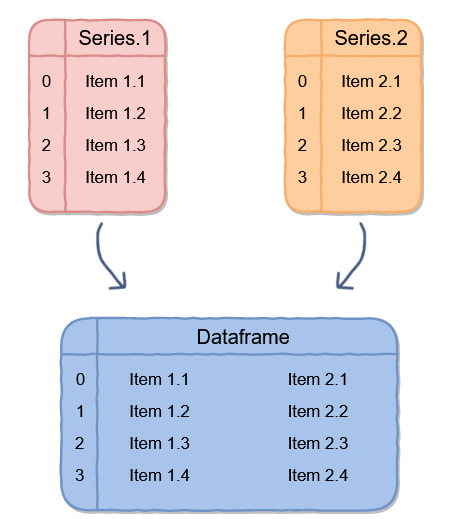

Por ter apenas uma coluna, pode ser criado de forma mais simples:

In [ ]:
pd.Series([30, 35, 40], index=['Vendas 2015', 'Vendas 2016', 'Vendas 2017'], name='Produto A')

,Produto A
Vendas 2015,30
Vendas 2016,35
Vendas 2017,40


Algumas funções retornam series ao invés de dataframes. Neste caso, para manipulação dos dados posteriormente é recomendado a conversão para dataframe.



In [ ]:
np.random.seed(0)
df_series = pd.Series(np.random.randint(0,100,size=(10)), index=['a','b','c','d','e','f','g','h','i','j'],name='A')
print(df_series)

print(pd.DataFrame(df_series, columns=['A']))



a    44
b    47
c    64
d    67
e    67
f     9
g    83
h    21
i    36
j    87
Name: A, dtype: int64
    A
a  44
b  47
c  64
d  67
e  67
f   9
g  83
h  21
i  36
j  87


Utilizando pandas, podemos ler tabelas já existentes (como do Excel), quando salvas em um arquivo CSV.



In [ ]:
#Uma estrátégia é utilizar documentos do drive
#Seguem os comandos para liberar o acesso ao drive

#from google.colab import drive
#drive.mount('/content/drive')


Entretando, vou utilizar o acesso direto ao meu gitHub público.
Importaremos o DataFrame "wine_reviews"

In [3]:

path = 'https://raw.githubusercontent.com/OrlandoIFPR/ml2/main/Dataframes/'
wine_reviews = pd.read_csv(path+ 'winemag-data-130k-v2.csv')
display(wine_reviews.head())
wine_reviews.shape


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


(129971, 14)

Viram que temos duas colunas duplicadas no começo do DataFrame? Isso é porque este DataFrame já vem com uma coluna dedicada ao index. Logo, vamos utilizar esta coluna, ao invés de criar uma nova:

In [4]:
reviews = pd.read_csv(path+ 'winemag-data-130k-v2.csv', index_col=0)
display(reviews.head())
reviews.shape

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


(129971, 13)

No Python nativo temos também como visualizar os dados, sem usar o head:


In [ ]:
reviews

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


Vamos limitar o quanto de informação aparece?

In [ ]:
pd.set_option('display.max_rows', 10)

reviews

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129966,Germany,Notes of honeysuckle and cantaloupe sweeten th...,Brauneberger Juffer-Sonnenuhr Spätlese,90,28.0,Mosel,NaN,NaN,Anna Lee C. Iijima,NaN,Dr. H. Thanisch (Erben Müller-Burggraef) 2013 ...,Riesling,Dr. H. Thanisch (Erben Müller-Burggraef)
129967,US,Citation is given as much as a decade of bottl...,NaN,90,75.0,Oregon,Oregon,Oregon Other,Paul Gregutt,@paulgwine,Citation 2004 Pinot Noir (Oregon),Pinot Noir,Citation
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


Podemos também acessar apenas as colunas:

In [ ]:
reviews['country'] #usando o conceito de dicionário para acessar uma key


,country
0,Italy
1,Portugal
2,US
3,US
4,US
...,...
129966,Germany
129967,US
129968,France
129969,France


In [ ]:
reviews.country #usando o atributo

,country
0,Italy
1,Portugal
2,US
3,US
4,US
...,...
129966,Germany
129967,US
129968,France
129969,France


Vejam que isso que fizemos foi indexação, utilizando os conceitos da aula passada. Podemos, similarmente, encontrar um dado específico:

In [ ]:
reviews['country'][0]

'Italy'

No pandas lidamos com DataFrames muito grandes, o que pode tornar a indexação direta mais complexa. Temos então os indexadores nativos do pandas: loc e iloc. Ambos funcionam com linha primeiro, coluna depois. iloc seleciona dados baseado no index (posição numérica dos dados):

In [ ]:

reviews.iloc[0]






,0
country,Italy
description,"Aromas include tropical fruit, broom, brimston..."
designation,Vulkà Bianco
points,87
price,NaN
...,...
taster_name,Kerin O’Keefe
taster_twitter_handle,@kerinokeefe
title,Nicosia 2013 Vulkà Bianco (Etna)
variety,White Blend


In [ ]:


reviews.iloc[:, 0]



0            Italy
1         Portugal
2               US
3               US
4               US
            ...   
129966     Germany
129967          US
129968      France
129969      France
129970      France
Name: country, Length: 129971, dtype: object

O loc funciona através de labels:

In [ ]:


reviews.loc[:, 'country']



,country
0,Italy
1,Portugal
2,US
3,US
4,US
...,...
129966,Germany
129967,US
129968,France
129969,France


In [ ]:


reviews.loc[:, ['taster_name', 'taster_twitter_handle', 'points']]



,taster_name,taster_twitter_handle,points
0,Kerin O’Keefe,@kerinokeefe,87
1,Roger Voss,@vossroger,87
2,Paul Gregutt,@paulgwine,87
3,Alexander Peartree,NaN,87
4,Paul Gregutt,@paulgwine,87
...,...,...,...
129966,Anna Lee C. Iijima,NaN,90
129967,Paul Gregutt,@paulgwine,90
129968,Roger Voss,@vossroger,90
129969,Roger Voss,@vossroger,90


Podemos usar o loc com condicionais! Mexa no código abaixo para usar OU |, AND &, < e >.


In [ ]:




reviews.loc[(reviews.country == 'Italy') & (reviews.points >= 90)]






,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
120,Italy,"Slightly backward, particularly given the vint...",Bricco Rocche Prapó,92,70.0,Piedmont,Barolo,NaN,NaN,NaN,Ceretto 2003 Bricco Rocche Prapó (Barolo),Nebbiolo,Ceretto
130,Italy,"At the first it was quite muted and subdued, b...",Bricco Rocche Brunate,91,70.0,Piedmont,Barolo,NaN,NaN,NaN,Ceretto 2003 Bricco Rocche Brunate (Barolo),Nebbiolo,Ceretto
133,Italy,"Einaudi's wines have been improving lately, an...",NaN,91,68.0,Piedmont,Barolo,NaN,NaN,NaN,Poderi Luigi Einaudi 2003 Barolo,Nebbiolo,Poderi Luigi Einaudi
135,Italy,The color is just beginning to show signs of b...,Sorano,91,60.0,Piedmont,Barolo,NaN,NaN,NaN,Giacomo Ascheri 2001 Sorano (Barolo),Nebbiolo,Giacomo Ascheri
140,Italy,"A big, fat, luscious wine with plenty of toast...",Costa Bruna,90,26.0,Piedmont,Barbera d'Alba,NaN,NaN,NaN,Poderi Colla 2005 Costa Bruna (Barbera d'Alba),Barbera,Poderi Colla
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129929,Italy,"This luminous sparkler has a sweet, fruit-forw...",NaN,91,38.0,Veneto,Prosecco Superiore di Cartizze,NaN,NaN,NaN,Col Vetoraz Spumanti NV Prosecco Superiore di...,Prosecco,Col Vetoraz Spumanti
129943,Italy,"A blend of Nero d'Avola and Syrah, this convey...",Adènzia,90,29.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,Baglio del Cristo di Campobello 2012 Adènzia R...,Red Blend,Baglio del Cristo di Campobello
129947,Italy,"A blend of 65% Cabernet Sauvignon, 30% Merlot ...",Symposio,90,20.0,Sicily & Sardinia,Terre Siciliane,NaN,Kerin O’Keefe,@kerinokeefe,Feudo Principi di Butera 2012 Symposio Red (Te...,Red Blend,Feudo Principi di Butera
129961,Italy,"Intense aromas of wild cherry, baking spice, t...",NaN,90,30.0,Sicily & Sardinia,Sicilia,NaN,Kerin O’Keefe,@kerinokeefe,COS 2013 Frappato (Sicilia),Frappato,COS


O que pode também ser feito com uma função nativa do Pandas, chamada isin:

In [ ]:


reviews.loc[ reviews.country.isin(['Italy', 'France']) ]



,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
6,Italy,"Here's a bright, informal red that opens with ...",Belsito,87,16.0,Sicily & Sardinia,Vittoria,NaN,Kerin O’Keefe,@kerinokeefe,Terre di Giurfo 2013 Belsito Frappato (Vittoria),Frappato,Terre di Giurfo
7,France,This dry and restrained wine offers spice in p...,NaN,87,24.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Trimbach 2012 Gewurztraminer (Alsace),Gewürztraminer,Trimbach
9,France,This has great depth of flavor with its fresh ...,Les Natures,87,27.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Jean-Baptiste Adam 2012 Les Natures Pinot Gris...,Pinot Gris,Jean-Baptiste Adam
11,France,"This is a dry wine, very spicy, with a tight, ...",NaN,87,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Leon Beyer 2012 Gewurztraminer (Alsace),Gewürztraminer,Leon Beyer
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129964,France,"Initially quite muted, this wine slowly develo...",Domaine Saint-Rémy Herrenweg,90,NaN,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Ehrhart 2013 Domaine Saint-Rémy Herren...,Gewürztraminer,Domaine Ehrhart
129965,France,"While it's rich, this beautiful dry wine also ...",Seppi Landmann Vallée Noble,90,28.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Rieflé-Landmann 2013 Seppi Landmann Va...,Pinot Gris,Domaine Rieflé-Landmann
129968,France,Well-drained gravel soil gives this wine its c...,Kritt,90,30.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Gresser 2013 Kritt Gewurztraminer (Als...,Gewürztraminer,Domaine Gresser
129969,France,"A dry style of Pinot Gris, this is crisp with ...",NaN,90,32.0,Alsace,Alsace,NaN,Roger Voss,@vossroger,Domaine Marcel Deiss 2012 Pinot Gris (Alsace),Pinot Gris,Domaine Marcel Deiss


Assim como o isnull e notnull:

In [ ]:
reviews.loc[reviews.price.isnull()]

,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
13,Italy,This is dominated by oak and oak-driven aromas...,Rosso,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Masseria Setteporte 2012 Rosso (Etna),Nerello Mascalese,Masseria Setteporte
30,France,Red cherry fruit comes laced with light tannin...,Nouveau,86,NaN,Beaujolais,Beaujolais-Villages,NaN,Roger Voss,@vossroger,Domaine de la Madone 2012 Nouveau (Beaujolais...,Gamay,Domaine de la Madone
31,Italy,Merlot and Nero d'Avola form the base for this...,Calanìca Nero d'Avola-Merlot,86,NaN,Sicily & Sardinia,Sicilia,NaN,NaN,NaN,Duca di Salaparuta 2010 Calanìca Nero d'Avola-...,Red Blend,Duca di Salaparuta
32,Italy,"Part of the extended Calanìca series, this Gri...",Calanìca Grillo-Viognier,86,NaN,Sicily & Sardinia,Sicilia,NaN,NaN,NaN,Duca di Salaparuta 2011 Calanìca Grillo-Viogni...,White Blend,Duca di Salaparuta
...,...,...,...,...,...,...,...,...,...,...,...,...,...
129844,Italy,"Doga delle Clavule is a neutral, mineral-drive...",Doga delle Clavule,86,NaN,Tuscany,Morellino di Scansano,NaN,NaN,NaN,Caparzo 2006 Doga delle Clavule (Morellino di...,Sangiovese,Caparzo
129860,Portugal,This rich wine has a firm structure as well as...,Pacheca Superior,90,NaN,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta da Pacheca 2013 Pacheca Superior Red (D...,Portuguese Red,Quinta da Pacheca
129863,Portugal,This mature wine that has 50% Touriga Nacional...,Reserva,90,NaN,Dão,NaN,NaN,Roger Voss,@vossroger,Seacampo 2011 Reserva Red (Dão),Portuguese Red,Seacampo
129893,Italy,"Aromas of passion fruit, hay and a vegetal not...",Corte Menini,91,NaN,Veneto,Soave Classico,NaN,Kerin O’Keefe,@kerinokeefe,Le Mandolare 2015 Corte Menini (Soave Classico),Garganega,Le Mandolare


Algumas funções de interesse em pandas:

`describe` #sumariza o dados -> bom para entender melhor as colunas do DataFrame

`mean` #média de dados numéricos

`unique` #retorna os dados não repetidos -> qual a utilidade?

`value_counts` #conta quantos dados não repetidos e retorna os dados e a contagem

`min` #retorna valor mínimo

`max` # retorna valor máximo


Faça alguns testes na célula de código abaixo!


In [ ]:
reviews.taster_name.unique()

array(['Kerin O’Keefe', 'Roger Voss', 'Paul Gregutt',
       'Alexander Peartree', 'Michael Schachner', 'Anna Lee C. Iijima',
       'Virginie Boone', 'Matt Kettmann', nan, 'Sean P. Sullivan',
       'Jim Gordon', 'Joe Czerwinski', 'Anne Krebiehl\xa0MW',
       'Lauren Buzzeo', 'Mike DeSimone', 'Jeff Jenssen',
       'Susan Kostrzewa', 'Carrie Dykes', 'Fiona Adams',
       'Christina Pickard'], dtype=object)

In [ ]:
reviews.taster_name.value_counts()

,count
taster_name,
Roger Voss,25514
Michael Schachner,15134
Kerin O’Keefe,10776
Virginie Boone,9537
Paul Gregutt,9532
...,...
Jeff Jenssen,491
Alexander Peartree,415
Carrie Dykes,139


Outras funções importantes são as de agrupamento, com groupby. Ela agrupa os dados iguais e tem atributos como aqueles vistos em numpy (mean, min, max...):

In [ ]:


reviews.groupby('points').price.mean()



,price
points,
80,16.372152
81,17.182353
82,18.870767
83,18.237353
84,19.310215
85,19.949562
86,22.133759
87,24.901884
88,28.687523



Você pode pensar em cada grupo que geramos como uma fatia de um DataFrame, contendo dados que combinam entre si. Usando o método apply, podemos manipular esses grupos:


In [ ]:


reviews_new=reviews.groupby(['country', 'province']).apply(lambda df: df.loc[df.points.idxmax()])
reviews_new


country  \
country   province                      
Argentina Mendoza Province  Argentina   
          Other             Argentina   
Armenia   Armenia             Armenia   
Australia Australia Other   Australia   
          New South Wales   Australia   
...                               ...   
Uruguay   Juanico             Uruguay   
          Montevideo          Uruguay   
          Progreso            Uruguay   
          San Jose            Uruguay   
          Uruguay             Uruguay   

                                                                  description  \
country   province                                                              
Argentina Mendoza Province  If the color doesn't tell the full story, the ...   
          Other             Take note, this could be the best wine Colomé ...   
Armenia   Armenia           Deep salmon in color, this wine offers a bouqu...   
Australia Australia Other   Writes the book on how to make a wine filled w...   
          New South Wales   De Bortoli's Noble One is as good as ever in 2...   
...                                                                       ...   
Uruguay   Juanico           This mature Bordeaux-style blend is earthy on ...   
          Montevideo        A rich, heady bouquet offers aromas of blackbe...   
          Progreso          Rusty in color but deep and complex in nature,...   
          San Jose          Baked, sweet, heavy aromas turn earthy with ti...   
          Uruguay           Cherry and berry aromas are ripe, healthy and ...   

                                                        designation  points  \
country   province                                                            
Argentina Mendoza Province                         Nicasia Vineyard      97   
          Other                                             Reserva      95   
Armenia   Armenia                                    Estate Bottled      88   
Australia Australia Other                             Sarah's Blend      93   
          New South Wales                        Noble One Bortytis      94   
...                                                             ...     ...   
Uruguay   Juanico                  Preludio Barrel Select Lote N 77      90   
          Montevideo        Monte Vide Eu Tannat-Merlot-Tempranillo      91   
          Progreso                   Etxe Oneko Fortified Sweet Red      90   
          San Jose                         El Preciado Gran Reserva      87   
          Uruguay                         Blend 002 Limited Edition      91   

                            price          province                 region_1  \
country   province                                                             
Argentina Mendoza Province  120.0  Mendoza Province                  Mendoza   
          Other              90.0             Other                    Salta   
Armenia   Armenia            15.0           Armenia                      NaN   
Australia Australia Other    15.0   Australia Other  South Eastern Australia   
          New South Wales    32.0   New South Wales          New South Wales   
...                           ...               ...                      ...   
Uruguay   Juanico            45.0           Juanico                      NaN   
          Montevideo         60.0        Montevideo                      NaN   
          Progreso           46.0          Progreso                      NaN   
          San Jose           50.0          San Jose                      NaN   
          Uruguay            22.0           Uruguay                      NaN   

                           region_2        taster_name taster_twitter_handle  \
country   province                                                             
Argentina Mendoza Province      NaN  Michael Schachner           @wineschach   
          Other                 NaN  Michael Schachner           @wineschach   
Armenia   Armenia               NaN      Mike DeSimon

Veja que agora temos 2 indexes para o novo DataFrame!

Se você precisar retornar a apenas um index, use reset_index.

Outra função importante é agg. Você pode agregar diversos métodos aplicados ao mesmo DataFrame em uma única linha de código:

In [ ]:


reviews.groupby(['country']).price.agg([len, "min", "max", "count", 'mean', 'std'])



,len,min,max,count,mean,std
country,,,,,,
Argentina,3800,4.0,230.0,3756,24.510117,23.430122
Armenia,2,14.0,15.0,2,14.500000,0.707107
Australia,2329,5.0,850.0,2294,35.437663,49.049458
Austria,3345,7.0,1100.0,2799,30.762772,27.224797
Bosnia and Herzegovina,2,12.0,13.0,2,12.500000,0.707107
...,...,...,...,...,...,...
Switzerland,7,21.0,160.0,7,85.285714,70.063577
Turkey,90,14.0,120.0,90,24.633333,13.799894
US,54504,4.0,2013.0,54265,36.573464,27.088857


Veja que o que temos é um DataFrame em que Country é o novo index.

Vamos ver como podemos ordenar os valores de um DataFrame? Primeiro encontre um DataFrame com os grupos country e province. Depois encontre a quantidade de vinhos em cada um desses subgrupos (em cada province). Depois, utilize sort para ordenar do maior para o menor:

In [ ]:
countries_reviewed = reviews.groupby(['country', 'province']).description.agg([len])


countries_reviewed = countries_reviewed.reset_index()


#countries_reviewed.sort_values(by='len', ascending=False)



countries_reviewed.sort_values(by=['country', 'len'])

countries_reviewed.iloc[0:5, [-2,-1]]




,province,len
0,Mendoza Province,3264
1,Other,536
2,Armenia,2
3,Australia Other,245
4,New South Wales,85


Por último, vamos testar a função describe.


In [ ]:
serie = pd.Series([15,20,12,16,10,11,12,15,9,10,12,17],
              index = ['jan','fev', 'mar',
                       'abr', 'mai', 'jun',
                       'jul', 'ago', 'set',
                       'out','nov', 'dez'])

serie



,0
jan,15
fev,20
mar,12
abr,16
mai,10
jun,11
jul,12
ago,15
set,9
out,10


In [ ]:
serie.describe()

count    12.000000
mean     13.250000
std       3.333712
min       9.000000
25%      10.750000
50%      12.000000
75%      15.250000
max      20.000000
dtype: float64

Observando o resultado dos quartis, percebemos que, em um quarto dos meses, o número da serie por mês foi inferior a 11; em metade dos meses foi inferior ou igual a 12; e em três quartos dos meses foi inferior a 16.

In [ ]:
reviews.describe()

,points,price
count,129971.000000,120975.000000
mean,88.447138,35.363389
std,3.039730,41.022218
min,80.000000,4.000000
25%,86.000000,17.000000
50%,88.000000,25.000000
75%,91.000000,42.000000
max,100.000000,3300.000000
